In [74]:
# Import Libraries
import pandas as pd 
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score,classification_report

In [75]:
# Loading data
dataset = pd.read_csv("../../Data/Churn Prediction Data/churn-bigml-80.csv")
dataset.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [76]:
# Display dataset details
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [77]:
# Check missing values
print(dataset.isna().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [78]:
# Check duplicated values
print(dataset.duplicated().sum())

0


In [79]:
# Converting categorical data into numerical data
dataset['International plan'] = dataset['International plan'].map({'No':0, 'Yes':1})
dataset['Voice mail plan'] = dataset['Voice mail plan'].map({'No':0, 'Yes':1})
dataset = pd.get_dummies(dataset, columns=['State'], drop_first=True).astype(int)
print(dataset.head())

   Account length  Area code  International plan  Voice mail plan  \
0             128        415                   0                1   
1             107        415                   0                1   
2             137        415                   0                0   
3              84        408                   1                0   
4              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25                265              110   
1                     26                161              123   
2                      0                243              114   
3                      0                299               71   
4                      0                166              113   

   Total day charge  Total eve minutes  Total eve calls  ...  State_SD  \
0                45                197               99  ...         0   
1                27                195              

In [80]:
# Rearranging columns
cols = ["Churn"]
dataset = dataset[cols + [col for col in dataset.columns if col not in cols]]
print(dataset.head())

   Churn  Account length  Area code  International plan  Voice mail plan  \
0      0             128        415                   0                1   
1      0             107        415                   0                1   
2      0             137        415                   0                0   
3      0              84        408                   1                0   
4      0              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25                265              110   
1                     26                161              123   
2                      0                243              114   
3                      0                299               71   
4                      0                166              113   

   Total day charge  Total eve minutes  ...  State_SD  State_TN  State_TX  \
0                45                197  ...         0         0         0   
1   

In [81]:
# Feature Selection
data = dataset.values
X = data[:, 1:]
y = data[:, 0]
print(X.shape)
print(y.shape)

(2666, 68)
(2666,)


In [82]:
# Splitting of dataset into training and testing sets
# 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [83]:
# Display training and testing sets shape
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(2132, 68) (534, 68)
(2132,) (534,)


In [84]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [85]:
# Linear SVM
linear_svm = SVC(kernel='linear', random_state=0)

linear_svm.fit(X_train,y_train)

SVC(kernel='linear', random_state=0)

In [86]:
# Predictions from linear svm
y_pred_linear = linear_svm.predict(X_test)

In [87]:
# Metrics
linear_accuracy = accuracy_score(y_test, y_pred_linear)
linear_precision = precision_score(y_test, y_pred_linear)
linear_recall = recall_score(y_test, y_pred_linear)

# AUC 
linear_scores = linear_svm.decision_function(X_test)
linear_auc = roc_auc_score(y_test, linear_scores)

In [88]:
print("Accuracy:", linear_accuracy)
print("Precision:", linear_precision)
print("Recall:", linear_recall)
print("AUC:", linear_auc)

print("\nClassification Report:") 
print(classification_report(y_test, y_pred_linear))

Accuracy: 0.8539325842696629
Precision: 0.5
Recall: 0.038461538461538464
AUC: 0.774403958614485

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       456
           1       0.50      0.04      0.07        78

    accuracy                           0.85       534
   macro avg       0.68      0.52      0.50       534
weighted avg       0.81      0.85      0.80       534



In [89]:
# RBF SVM
rbf_svm = SVC(kernel='rbf', random_state=0)

rbf_svm.fit(X_train, y_train)

SVC(random_state=0)

In [90]:
# Predictions from RBF SVM 
y_pred_rbf = rbf_svm.predict(X_test)

In [91]:
# Metrics
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
rbf_precision = precision_score(y_test, y_pred_rbf)
rbf_recall = recall_score(y_test, y_pred_rbf)

# AUC 
rbf_scores = rbf_svm.decision_function(X_test)
rbf_auc = roc_auc_score(y_test, rbf_scores)

In [92]:
print("Accuracy :", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall :", rbf_recall)
print("AUC :", rbf_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

Accuracy : 0.8576779026217228
Precision: 0.5833333333333334
Recall : 0.08974358974358974
AUC : 0.8375224921277553

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       456
           1       0.58      0.09      0.16        78

    accuracy                           0.86       534
   macro avg       0.72      0.54      0.54       534
weighted avg       0.82      0.86      0.81       534



In [93]:
# Comparison of linear and rbf svm models
comparison = pd.DataFrame({ 
    'Metric': ['Accuracy', 'Precision', 'Recall', 'AUC'], 
    'Linear SVM': [ linear_accuracy, linear_precision, linear_recall, linear_auc ], 
    'RBF SVM': [ rbf_accuracy, rbf_precision, rbf_recall, rbf_auc ] 
    })

print(comparison)

      Metric  Linear SVM   RBF SVM
0   Accuracy    0.853933  0.857678
1  Precision    0.500000  0.583333
2     Recall    0.038462  0.089744
3        AUC    0.774404  0.837522


In [94]:
# Reduce the features to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=0)

X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

In [95]:
# Train Linear SVM on the 2D data
linear_svm_2d = SVC(kernel='linear', random_state=0)
linear_svm_2d.fit(X_train_2d, y_train)

SVC(kernel='linear', random_state=0)

In [96]:
# Train RBF SVM on the 2D data
rbf_svm_2d = SVC(kernel='rbf', random_state=0)
rbf_svm_2d.fit(X_train_2d, y_train)

SVC(random_state=0)

In [97]:
# Create mesh grid
x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

In [ ]:
# Predictions for the mesh grid
Z_linear = linear_svm_2d.predict(grid)
Z_rbf = rbf_svm_2d.predict(grid)

Z_linear = Z_linear.reshape(xx.shape)
Z_rbf = Z_rbf.reshape(xx.shape)

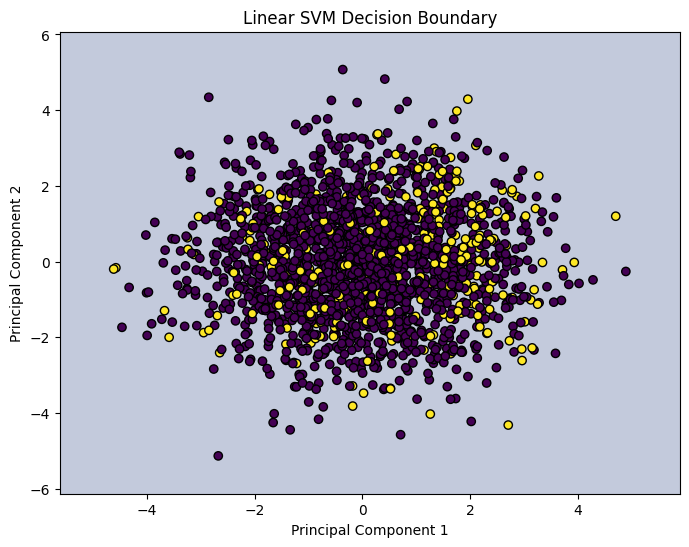

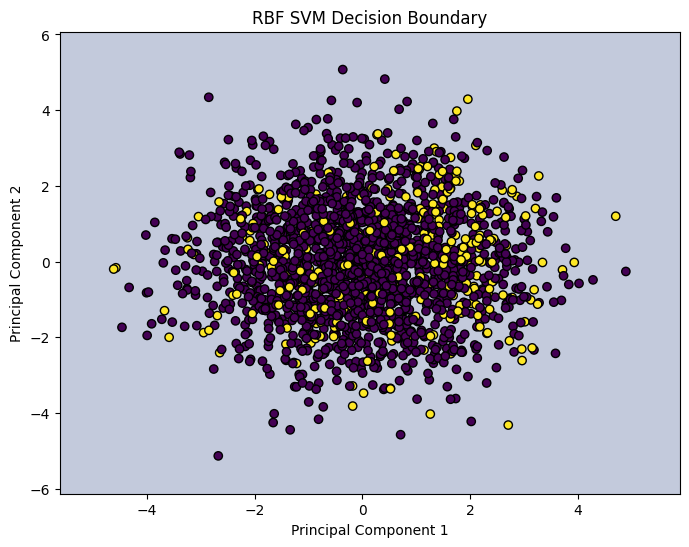

In [ ]:
# Linear SVM decision boundary
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z_linear, alpha=0.3)
plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    edgecolors='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Linear SVM Decision Boundary")
plt.show()

# RBF SVM decision boundary
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z_rbf, alpha=0.3)
plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    edgecolors='k'
)

plt.xlabel("Principal Component 1") 
plt.ylabel("Principal Component 2")
plt.title("RBF SVM Decision Boundary")
plt.show()